# Testing Performance Metrics For The Agent

In [1]:
import pandas as pd

In [2]:
df = pd.read_json("sms_conversations.json")

In [3]:
df

,conversation_id,candidate_phone,recruiter_phone,start_time_utc,turns
0,1,+1-555-0201,+1-555-0000,2026-04-03T15:12:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
1,2,+1-555-0202,+1-555-0000,2026-04-30T11:19:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
2,3,+1-555-0203,+1-555-0000,2026-04-10T16:02:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
3,4,+1-555-0204,+1-555-0000,2026-04-28T11:13:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
4,5,+1-555-0205,+1-555-0000,2026-04-26T12:43:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
5,6,+1-555-0206,+1-555-0000,2026-04-16T16:45:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
6,7,+1-555-0207,+1-555-0000,2026-04-12T12:15:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
7,8,+1-555-0208,+1-555-0000,2026-04-03T12:49:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
8,9,+1-555-0209,+1-555-0000,2026-04-17T17:20:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."
9,10,+1-555-0210,+1-555-0000,2026-04-27T13:30:00Z,"[{'turn_id': 1, 'speaker': 'recruiter', 'times..."


## The Data

<p>
We got some conversations to test on: the file contains <i>convesation id</i> which is equivalent to <i>Session id</i> in our code, some <i>meta data</i> on the conversation, and the <i>turns</i> in each conversation.
</p>
<p>
We need to create a turn based test bench, which takes the turns in each conversation and checks if the agent is following the script as he should or not.
</p>



### The Evaluation Process is as follows: 
1. Load the conversations - already done up there
2. Extract the label from each turn in each conversation.
3. Extract the initial prompt from each conversation.
4. Extract the user's prompts from each conversation.
5. Start the Agent with the initial response.
6. Send the user's prompt to the Agent in each turn.
7. Get the agent's response and intention for each user prompt.
8. Evaluate the agent's intention against the extracted label.
9. Save the agent's intentions into an array.
10. Create a confusion matrix for each label ('continue', 'schedule', 'exit')


In [4]:
import os
from dotenv import load_dotenv

os.chdir('../')
os.getcwd()


'c:\\Users\\w9x5i0\\Documents\\GENAI technion\\Scripting\\FinalProject\\FinalProject'

In [5]:
from langchain.tools import tool
from app.modules.agents.agents import Agent
from app.modules.embedding import build_search_job_description_tool, Embedder
from app.modules.sql_interface.schedule_db import build_schedule_tools

load_dotenv()

# ollama chat llms: gemma4:e4b

# Create an Embedding db if not found:
if 'chroma_db' not in os.listdir():
    embed = Embedder()

    embed.build_vectorstore('../Python Developer Job Description.pdf')

# Create the info tool function
load_info = build_search_job_description_tool()

# Create schedule tools with db connection, using python dev as default position
schedule_tools = build_schedule_tools()

In [6]:
# Load api key
openai_api_key = os.getenv('OPENAI_API_KEY')
openai_api_key[:5]

'sk-pr'

In [7]:
for i,r in df.iterrows():
    print(r)

conversation_id                                                    1
candidate_phone                                          +1-555-0201
recruiter_phone                                          +1-555-0000
start_time_utc                                  2026-04-03T15:12:00Z
turns              [{'turn_id': 1, 'speaker': 'recruiter', 'times...
Name: 0, dtype: object
conversation_id                                                    2
candidate_phone                                          +1-555-0202
recruiter_phone                                          +1-555-0000
start_time_utc                                  2026-04-30T11:19:00Z
turns              [{'turn_id': 1, 'speaker': 'recruiter', 'times...
Name: 1, dtype: object
conversation_id                                                    3
candidate_phone                                          +1-555-0203
recruiter_phone                                          +1-555-0000
start_time_utc                                  2026-04-1

In [ ]:
intentions_list = []

Errors = []

for i,r in df.iterrows():
    user_message = None
    message = r['turns'][0]['text']
    @tool
    def get_conversation_time()-> str:
        '''Returns the start time of the conversation.'''
        return r['start_time_utc']

    sys_msg =f""""The User's application has been received successfully. The User will be redirected to you."
    Following the provided formatting rules, output this: {message},
    to the user **First**, and after that you can continue normally."""

    agent = Agent(
        api_key = openai_api_key,# api_key="ollama",
        model= 'o4-mini', # 'gpt-4o-mini',# model="gemma4:e4b", 
        # base_url="http://localhost:11434/v1",
        system_message=sys_msg,
        sch_tools=schedule_tools+[get_conversation_time],
        info_tools=[load_info],
        temperature = 1,
        verbose=True
    )

    for turn in r['turns']:
        print('-'*60)
        if turn['turn_id'] == 1:
            ai_message = agent.step('candidate',training=True)
        # at candidate turn generate the ai response
        if turn['speaker'] == 'candidate':
            print(turn['text'])
            ai_message = agent.step('candidate', turn['text'],training=True)
        # at the recruiter turn print the response and the intention
        elif turn['speaker'] == 'recruiter':
            try:
                print(ai_message['response'])
            except KeyError:
                Errors.append(ai_message)
                print('KeyError', ai_message)
            print('Recruiter Label:')
            print(turn['label'])
            print('Assistant Label:')
            try:
                intentions_list.append((i, turn['turn_id'], ai_message['intention']))
                print(ai_message['intention'])
            except IndexError:
                Errors.append(ai_message)
                intentions_list.append((i, turn['turn_id'], 'continue'))
                print('IndexError:', 'continue')
            except KeyError:
                Errors.append(ai_message)
                intentions_list.append((i, turn['turn_id'], 'continue'))
                print('KeyError:', 'continue')

    print('-'*60)
    print('Agent Intentions in the conversation:')
    print(intentions_list)
    print('-'*60)
    print('Summaries in conversation:')
    print(agent.summary_counter)
    print('-'*60)
    print('Errors in conversation:')
    print(Errors)

c:\Users\w9x5i0\Documents\GENAI technion\Scripting\FinalProject\FinalProject\app\modules\agents\agents.py:139: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  self.main_agent = self.build_agent(self.llm, f"agents_Instructions{path_sep}main_agent.md", tools=[choose_advisor],has_history=True)


------------------------------------------------------------


> Entering new AgentExecutor chain...
{"intention":"continue","response":"Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?"}

> Finished chain.
Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?
Recruiter Label:
continue
Assistant Label:
continue
------------------------------------------------------------
I've been using Python professionally for five years, mostly for data analysis.


> Entering new AgentExecutor chain...

Invoking: `choose_advisor` with `{'advisor': 'Info'}`




> Entering new AgentExecutor chain...
Great to hear you’re interested in our Python Developer role! Could you tell me about a few of the Python projects you’ve worked on recently? For each, just a brief overview of:

• The project’s goal or domain  
• Your specific responsibilities and the technologies or frameworks you used

c:\Users\w9x5i0\Documents\GENAI technion\Scripting\FinalProject\FinalProject\app\modules\agents\agents.py:139: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  self.main_agent = self.build_agent(self.llm, f"agents_Instructions{path_sep}main_agent.md", tools=[choose_advisor],has_history=True)


{"intention":"continue","response":"Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?"}

> Finished chain.
Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?
Recruiter Label:
continue
Assistant Label:
continue
------------------------------------------------------------
I have three years' experience with Django and Flask.


> Entering new AgentExecutor chain...

Invoking: `choose_advisor` with `{'advisor': 'Schedule', 'output': 'The candidate has 3 years experience with Django and Flask and is ready to schedule an interview. Please provide available slots.'}`




> Entering new AgentExecutor chain...

Invoking: `get_conversation_time` with `{}`


2026-04-30T11:19:00Z
Invoking: `check_availability` with `{'from_date': '2026-05-03', 'limit': 3}`


{"slots": [{"date": "2026-05-03", "time": "11:00"}, {"date": "2026-05-03", "time": "12:00"},

c:\Users\w9x5i0\Documents\GENAI technion\Scripting\FinalProject\FinalProject\app\modules\agents\agents.py:139: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  self.main_agent = self.build_agent(self.llm, f"agents_Instructions{path_sep}main_agent.md", tools=[choose_advisor],has_history=True)


...

{"intention":"continue","response":"Hello! I saw your application for the Python Developer position—how long have you been working with Python?"}

> Finished chain.
Hello! I saw your application for the Python Developer position—how long have you been working with Python?
Recruiter Label:
continue
Assistant Label:
continue
------------------------------------------------------------
I primarily work with Python for backend services and have solid SQL knowledge.


> Entering new AgentExecutor chain...

Invoking: `choose_advisor` with `{'advisor': 'Info', 'output': "The user said they primarily work with Python for backend services and have solid SQL knowledge, but didn't mention duration. What should I do next?"}`




> Entering new AgentExecutor chain...
You’re on the right track. Since we don’t yet know how long they’ve been coding in Python, let’s ask one targeted follow-up to fill that gap—and then we can guide them toward the next step (an interview).

Here’s what I’d suggest the b

c:\Users\w9x5i0\Documents\GENAI technion\Scripting\FinalProject\FinalProject\app\modules\agents\agents.py:139: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  self.main_agent = self.build_agent(self.llm, f"agents_Instructions{path_sep}main_agent.md", tools=[choose_advisor],has_history=True)


{"intention":"continue","response":"Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?"}

> Finished chain.
Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?
Recruiter Label:
continue
Assistant Label:
continue
------------------------------------------------------------
Sure, I have four years of Python experience.


> Entering new AgentExecutor chain...

Invoking: `choose_advisor` with `{'advisor': 'Schedule', 'output': 'Candidate has 4 years of Python experience and is ready to schedule an interview.'}`




> Entering new AgentExecutor chain...

Invoking: `get_conversation_time` with `{}`


2026-04-22T17:51:00Z
Invoking: `check_availability` with `{'from_date': '2026-04-26', 'limit': 3}`


{"slots": [{"date": "2026-04-26", "time": "09:00"}, {"date": "2026-04-26", "time": "10:00"}, {"date": "2026-04-26", "time": "14:00"}]}Great! Let’s g

c:\Users\w9x5i0\Documents\GENAI technion\Scripting\FinalProject\FinalProject\app\modules\agents\agents.py:139: LangChainDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  self.main_agent = self.build_agent(self.llm, f"agents_Instructions{path_sep}main_agent.md", tools=[choose_advisor],has_history=True)


{"intention":"continue","response":"Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?"}

> Finished chain.
Hi, thanks for submitting your application for our Python Developer role. Could you share a bit about your Python experience?
Recruiter Label:
continue
Assistant Label:
continue
------------------------------------------------------------
I've been using Python professionally for five years, mostly for ML.


> Entering new AgentExecutor chain...

Invoking: `choose_advisor` with `{'advisor': 'Schedule', 'output': 'The user is ready to schedule an interview. Please provide available slots next week for a 45-minute technical interview.'}`




> Entering new AgentExecutor chain...

Invoking: `get_conversation_time` with `{}`


2026-04-27T15:07:00Z
Invoking: `check_availability` with `{'from_date': '2026-05-03', 'limit': 3}`


{"slots": [{"date": "2026-05-03", "time": "11:00"}, {"date": "2026-05-03", "time": "1

In [9]:
test_df = pd.DataFrame(intentions_list)
test_df.head()

,0,1,2
0,0,1,continue
1,0,3,continue
2,0,5,schedule
3,0,7,schedule
4,1,1,continue


In [10]:
test_df = test_df.rename(columns={0:'conversation_id', 1:'turn_id', 2:'intention'})
test_df['conversation_id'] += 1
test_df.head()

,conversation_id,turn_id,intention
0,1,1,continue
1,1,3,continue
2,1,5,schedule
3,1,7,schedule
4,2,1,continue


In [11]:
tmp = pd.DataFrame()
for i,turn in enumerate(df.turns):
    tmp_df = pd.DataFrame(turn)
    tmp_df['conversation_id'] = i+1
    tmp = pd.concat([tmp,tmp_df],ignore_index=True)
tmp.head()

,turn_id,speaker,timestamp_utc,text,label,conversation_id
0,1,recruiter,2026-04-03T15:12:00Z,Thanks for applying to our Python Developer op...,continue,1
1,2,candidate,2026-04-03T15:13:19Z,I've been using Python professionally for five...,NaN,1
2,3,recruiter,2026-04-03T15:15:01Z,Our engineering manager can interview you Wedn...,schedule,1
3,4,candidate,2026-04-03T15:15:33Z,I can't at that time—I'm busy.,NaN,1
4,5,recruiter,2026-04-03T15:16:23Z,No problem. How about Thursday at 4 PM instead?,schedule,1


In [12]:
labels_df=tmp[tmp['speaker']=='recruiter'][['conversation_id','turn_id','label']]
labels_df.head()

,conversation_id,turn_id,label
0,1,1,continue
2,1,3,schedule
4,1,5,schedule
6,1,7,end
7,2,1,continue


In [13]:
dfs = pd.merge(test_df, labels_df,on=['conversation_id','turn_id'])
dfs.head()

,conversation_id,turn_id,intention,label
0,1,1,continue,continue
1,1,3,continue,schedule
2,1,5,schedule,schedule
3,1,7,schedule,end
4,2,1,continue,continue


In [14]:
dfs.intention = dfs.intention.str.replace("exit",'end')
dfs.head()

,conversation_id,turn_id,intention,label
0,1,1,continue,continue
1,1,3,continue,schedule
2,1,5,schedule,schedule
3,1,7,schedule,end
4,2,1,continue,continue


In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


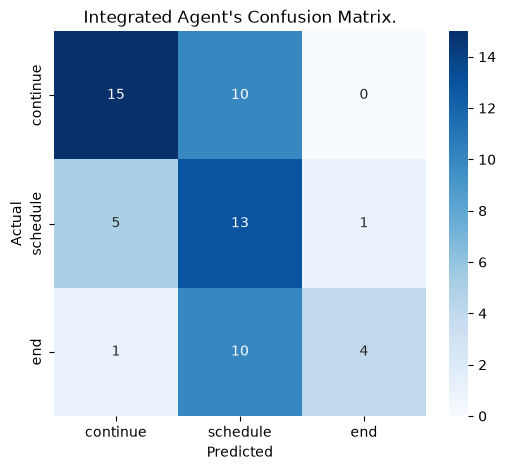

In [16]:
cf = confusion_matrix(dfs.label, dfs.intention,labels=['continue', 'schedule', 'end'])

plt.figure(figsize=(6,5))
sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
plt.title("Integrated Agent's Confusion Matrix.")
plt.xticks([0.5,1.5,2.5],labels=['continue', 'schedule', 'end'])
plt.yticks([0.5,1.5,2.5],labels=['continue', 'schedule', 'end'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("CFmatrix2.png")
plt.show()


In [17]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(dfs.label, dfs.intention)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.54


## Conclusion so far
<p>
We Can see from the confusion matrix that the currently used model is getting confused in the scheduling phase.
</p>

<p>
The cause can be that the instructions are somehow confusing it.
</p>

In [21]:
len(dfs.label.to_list())

59

In [23]:
import numpy as np
def simple_calssify():
    return ['continue']*59
simple_calssify()


['continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue',
 'continue']

In [24]:

# check classification against this simple function:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(dfs.label.to_list(), simple_calssify())
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.42
